# Exercício 1 — Busca em estruturas lineares e impacto da organização

Aluno: Henrique Goldstein Maluhy Mendes Amaral · DR1_AT · Infnet

Para rodar: Ambiente de execução → Executar tudo.

In [1]:
import random
import sys
import time

import matplotlib.pyplot as plt
import pandas as pd

# mesma semente = mesmos números em toda execução
random.seed(42)

## 1. Busca linear e busca binária

As duas funções devolvem `(posição, comparações)`, e a posição é -1 quando o valor não está no vetor. Na binária eu conto uma comparação por iteração: comparar o alvo com o elemento do meio já decide para que lado seguir.

In [2]:
class VetorNaoOrdenadoError(Exception):
    """A busca binária recebeu um vetor que não está ordenado."""


def linear_search(arr, target):
    comparacoes = 0
    for i in range(len(arr)):
        comparacoes += 1
        if arr[i] == target:
            return i, comparacoes
    return -1, comparacoes


def binary_search(sorted_arr, target, verificacao="amostra"):
    # pré-condição explícita: sem vetor ordenado a resposta da binária não vale nada
    verificar_ordenacao(sorted_arr, verificacao)

    comparacoes = 0
    inicio, fim = 0, len(sorted_arr) - 1
    while inicio <= fim:
        meio = (inicio + fim) // 2
        comparacoes += 1
        if sorted_arr[meio] == target:
            return meio, comparacoes
        elif sorted_arr[meio] < target:
            inicio = meio + 1   # o alvo só pode estar na metade da direita
        else:
            fim = meio - 1      # o alvo só pode estar na metade da esquerda
    return -1, comparacoes

## 2. Pré-condição da busca binária e falha rápida

A busca binária só funciona com o vetor ordenado. Num vetor fora de ordem ela não dá erro, só devolve uma resposta errada. Por isso ela confere a ordem antes de buscar e, se o vetor não estiver ordenado, levanta `VetorNaoOrdenadoError`. Não devolvo -1 nesse caso porque -1 quer dizer "não achei", e aqui o problema é a entrada.

A verificação tem três modos:
- `completa`: confere todos os pares vizinhos, O(n). É certeira, mas anula a vantagem da busca O(log n).
- `amostra`: confere só k pares vizinhos sorteados, O(k). É a falha rápida: bem mais barata que ordenar o vetor (O(n log n)) ou conferir tudo.
- `nenhuma`: para quando quem chama já garante a ordem.

In [3]:
AMOSTRA_PADRAO = 20   # quantos pares vizinhos a verificação por amostra confere


def verificar_ordenacao(arr, modo="amostra", k=AMOSTRA_PADRAO):
    """Levanta VetorNaoOrdenadoError se achar um par vizinho fora de ordem.
    Devolve quantas comparações gastou."""
    n = len(arr)
    if modo == "nenhuma" or n < 2:
        return 0

    if modo == "completa":
        posicoes = range(n - 1)
    elif modo == "amostra":
        # sorteio k posições; o par conferido é (i, i+1)
        posicoes = [random.randrange(n - 1) for _ in range(min(k, n - 1))]
    else:
        raise ValueError(f"modo de verificação desconhecido: {modo}")

    comparacoes = 0
    for i in posicoes:
        comparacoes += 1
        if arr[i] > arr[i + 1]:
            raise VetorNaoOrdenadoError(
                f"posição {i} ({arr[i]}) é maior que a posição {i + 1} ({arr[i + 1]})"
            )
    return comparacoes

## 3. Gerador de vetores

Os valores vão de 0 a n-1, sem repetição.

In [4]:
def gerar_vetor(n, cenario):
    if cenario == "ordenado":
        return list(range(n))
    if cenario == "reverso":
        return list(range(n - 1, -1, -1))
    if cenario == "aleatorio":
        vetor = list(range(n))
        random.shuffle(vetor)
        return vetor
    raise ValueError(f"cenário desconhecido: {cenario}")


# conferindo o gerador e as duas buscas antes de medir qualquer coisa
v = gerar_vetor(10, "ordenado")
assert v == [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
assert gerar_vetor(5, "reverso") == [4, 3, 2, 1, 0]
assert sorted(gerar_vetor(100, "aleatorio")) == list(range(100))

assert linear_search(v, 7) == (7, 8)      # achou na posição 7, depois de 8 comparações
assert linear_search(v, 99) == (-1, 10)   # não achou: comparou com todos
assert binary_search(v, 7)[0] == 7
assert binary_search(v, 99)[0] == -1
print("buscas e gerador conferidos")

buscas e gerador conferidos


## 4. Medição em 5 escalas (10² a 10⁶)

Para cada tamanho e cenário: linear no melhor caso (alvo na primeira posição), no caso médio (média de 10 alvos sorteados) e no pior caso (alvo ausente), e binária no pior caso (alvo ausente).

In [5]:
TAMANHOS = [10**2, 10**3, 10**4, 10**5, 10**6]
CENARIOS = ["ordenado", "reverso", "aleatorio"]

linhas = []
for n in TAMANHOS:
    for cenario in CENARIOS:
        vetor = gerar_vetor(n, cenario)

        _, melhor = linear_search(vetor, vetor[0])
        # alvo ausente: n nunca está no vetor (os valores vão de 0 a n-1).
        # Uso um valor MAIOR que todos porque é o que leva a binária ao pior caso:
        # o meio arredonda para baixo, então a metade da direita é a maior.
        _, pior = linear_search(vetor, n)
        amostra = [random.randrange(n) for _ in range(10)]
        medio = sum(linear_search(vetor, alvo)[1] for alvo in amostra) / len(amostra)

        try:
            _, binaria = binary_search(vetor, n)
        except VetorNaoOrdenadoError:
            binaria = "pré-condição falhou"

        linhas.append({
            "n": n,
            "cenario": cenario,
            "linear_melhor": melhor,
            "linear_medio": round(medio),
            "linear_pior": pior,
            "linear_pior / n": pior / n,
            "binaria_pior": binaria,
        })

tabela = pd.DataFrame(linhas)
tabela

,n,cenario,linear_melhor,linear_medio,linear_pior,linear_pior / n,binaria_pior
0,100,ordenado,1,47,100,1.0,7
1,100,reverso,1,56,100,1.0,pré-condição falhou
2,100,aleatorio,1,54,100,1.0,pré-condição falhou
3,1000,ordenado,1,463,1000,1.0,10
4,1000,reverso,1,528,1000,1.0,pré-condição falhou
5,1000,aleatorio,1,549,1000,1.0,pré-condição falhou
6,10000,ordenado,1,5397,10000,1.0,14
7,10000,reverso,1,6152,10000,1.0,pré-condição falhou
8,10000,aleatorio,1,4738,10000,1.0,pré-condição falhou
9,100000,ordenado,1,57230,100000,1.0,17


Na busca linear o pior caso é sempre n comparações (`linear_pior / n` = 1,0 nas cinco escalas), o melhor caso é 1 e o caso médio fica perto de n/2. Então ela é O(n), e a ordem do vetor não faz diferença. A binária só roda no vetor ordenado; nos outros cenários a verificação barra antes.

In [6]:
ordenado = tabela[tabela["cenario"] == "ordenado"].copy()
ordenado["log2(n)"] = [int(n).bit_length() for n in ordenado["n"]]   # bit_length(n) = ⌊log2 n⌋ + 1

print("busca binária no vetor ordenado, pior caso (alvo ausente):\n")
for _, linha in ordenado.iterrows():
    assert linha["binaria_pior"] == linha["log2(n)"]   # bate exatamente com a teoria
    print(f"  n = {linha['n']:>9,}   comparações = {linha['binaria_pior']:>2}"
          f"   ⌊log2 n⌋+1 = {linha['log2(n)']:>2}   linear faria {linha['linear_pior']:>9,}")

busca binária no vetor ordenado, pior caso (alvo ausente):

  n =       100   comparações =  7   ⌊log2 n⌋+1 =  7   linear faria       100
  n =     1,000   comparações = 10   ⌊log2 n⌋+1 = 10   linear faria     1,000
  n =    10,000   comparações = 14   ⌊log2 n⌋+1 = 14   linear faria    10,000
  n =   100,000   comparações = 17   ⌊log2 n⌋+1 = 17   linear faria   100,000
  n = 1,000,000   comparações = 20   ⌊log2 n⌋+1 = 20   linear faria 1,000,000


A binária faz no máximo ⌊log₂ n⌋ + 1 comparações, porque cada passo descarta metade do vetor. De 10² para 10⁶ ela vai de 7 para 20 comparações, enquanto a linear vai de 100 para 1.000.000.

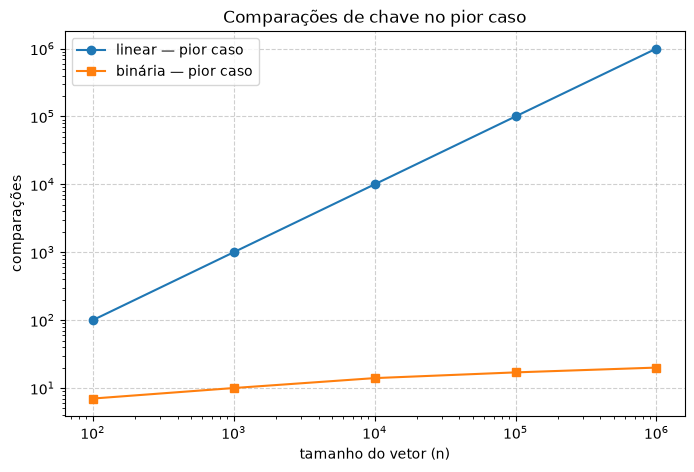

In [7]:
plt.figure(figsize=(8, 5))
plt.plot(ordenado["n"], ordenado["linear_pior"], marker="o", label="linear — pior caso")
plt.plot(ordenado["n"], ordenado["binaria_pior"], marker="s", label="binária — pior caso")
plt.xscale("log")
plt.yscale("log")
plt.title("Comparações de chave no pior caso")
plt.xlabel("tamanho do vetor (n)")
plt.ylabel("comparações")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.show()

No gráfico em escala log-log a linear sobe em linha reta, com inclinação 1, e a binária quase não sai do lugar.

## 5. A falha rápida funciona? E o risco de falso positivo

A amostra nunca acusa um vetor ordenado de estar fora de ordem, mas pode deixar passar um vetor fora de ordem se nenhum dos k pares sorteados estiver errado. Esse é o falso positivo. O risco depende de quantos pares estão fora de ordem: no aleatório e no reverso quase todos estão, e a amostra pega; num vetor com uma única troca, a chance de pegar é só k/(n-1).

In [8]:
def quase_ordenado(n):
    vetor = list(range(n))
    i = random.randrange(n - 1)
    vetor[i], vetor[i + 1] = vetor[i + 1], vetor[i]   # uma única troca de vizinhos
    return vetor


n = 10_000
tentativas = 500
casos = {
    "aleatorio": lambda: gerar_vetor(n, "aleatorio"),
    "reverso": lambda: gerar_vetor(n, "reverso"),
    "quase ordenado (1 troca)": lambda: quase_ordenado(n),
}

resultado = []
for nome, fabrica in casos.items():
    detectou = 0
    for _ in range(tentativas):
        try:
            verificar_ordenacao(fabrica(), "amostra")
        except VetorNaoOrdenadoError:
            detectou += 1
    resultado.append({
        "cenario": nome,
        "detectou": f"{detectou}/{tentativas}",
        "taxa_de_deteccao": detectou / tentativas,
        "falso_positivo": 1 - detectou / tentativas,
    })

print(f"n = {n:,}, k = {AMOSTRA_PADRAO} pares sorteados, {tentativas} vetores por cenário")
print(f"previsão para 1 troca: k/(n-1) = {AMOSTRA_PADRAO / (n - 1):.4f}\n")
pd.DataFrame(resultado)

n = 10,000, k = 20 pares sorteados, 500 vetores por cenário
previsão para 1 troca: k/(n-1) = 0.0020



,cenario,detectou,taxa_de_deteccao,falso_positivo
0,aleatorio,500/500,1.000,0.000
1,reverso,500/500,1.000,0.000
2,quase ordenado (1 troca),1/500,0.002,0.998


Foi o que a medição mostrou: a amostra pegou todos os vetores aleatórios e reversos, e só 0,2% dos que tinham uma troca, igual à previsão k/(n-1). Então ela serve como proteção barata contra erro grosseiro, não como garantia. Quando a ordem precisa ser garantida, o certo é usar a verificação completa ou ordenar o vetor na origem.

## 6. A mesma busca linear numa `SinglyLinkedList`

Lista mínima, como pede o enunciado: o nó tem só `value` e `next`.

In [9]:
class Node:
    def __init__(self, value):
        self.value = value
        self.next = None


class SinglyLinkedList:
    def __init__(self):
        self.head = None
        self.tail = None   # guardo o último nó para inserir no fim sem percorrer tudo

    def insert_last(self, value):
        novo = Node(value)
        if self.head is None:
            self.head = novo
        else:
            self.tail.next = novo
        self.tail = novo


def linear_search_linked(lista, target):
    comparacoes = 0
    posicao = 0
    atual = lista.head
    while atual is not None:
        comparacoes += 1
        if atual.value == target:
            return posicao, comparacoes
        atual = atual.next      # sem índice: só dá para andar de nó em nó
        posicao += 1
    return -1, comparacoes


def lista_de(vetor):
    lista = SinglyLinkedList()
    for valor in vetor:
        lista.insert_last(valor)
    return lista


# mesma resposta que a versão em array
lista = lista_de([5, 3, 8])
assert linear_search_linked(lista, 8) == (2, 3)
assert linear_search_linked(lista, 9) == (-1, 3)
assert linear_search_linked(SinglyLinkedList(), 1) == (-1, 0)
print("busca linear na lista conferida")

busca linear na lista conferida


### Array × lista encadeada, com os mesmos dados

Mesmo vetor e mesmos alvos nas duas estruturas.

In [10]:
def tamanho_em_bytes(lista):
    # soma o tamanho de cada nó; o valor em si é o mesmo objeto nas duas estruturas
    total = sys.getsizeof(lista)
    atual = lista.head
    while atual is not None:
        total += sys.getsizeof(atual) + sys.getsizeof(atual.__dict__)
        atual = atual.next
    return total


comparacao = []
for n in [10**3, 10**4, 10**5]:
    vetor = gerar_vetor(n, "aleatorio")
    lista = lista_de(vetor)
    alvos = [random.randrange(n) for _ in range(20)] + [-1]   # 20 presentes + 1 ausente

    comp_array = comp_lista = 0
    inicio = time.perf_counter()
    for alvo in alvos:
        comp_array += linear_search(vetor, alvo)[1]
    tempo_array = time.perf_counter() - inicio

    inicio = time.perf_counter()
    for alvo in alvos:
        comp_lista += linear_search_linked(lista, alvo)[1]
    tempo_lista = time.perf_counter() - inicio

    comparacao.append({
        "n": n,
        "comparacoes_array": comp_array,
        "comparacoes_lista": comp_lista,
        "iguais?": comp_array == comp_lista,
        "ns_por_comparacao_array": tempo_array / comp_array * 1e9,
        "ns_por_comparacao_lista": tempo_lista / comp_lista * 1e9,
        "memoria_array_KB": sys.getsizeof(vetor) / 1024,
        "memoria_lista_KB": tamanho_em_bytes(lista) / 1024,
    })

df = pd.DataFrame(comparacao)
df["lista/array (memória)"] = df["memoria_lista_KB"] / df["memoria_array_KB"]
df

,n,comparacoes_array,comparacoes_lista,iguais?,ns_por_comparacao_array,ns_por_comparacao_lista,memoria_array_KB,memoria_lista_KB,lista/array (memória)
0,1000,9271,9271,True,100.884479,86.948549,7.867188,132.859375,16.887786
1,10000,108754,108754,True,34.574360,42.083969,78.179688,1328.171875,16.988708
2,100000,923397,923397,True,53.131210,48.175595,781.304688,13281.296875,16.998870


As comparações são exatamente iguais (coluna `iguais?`): o algoritmo é o mesmo e as duas são O(n). A diferença prática está na memória: a lista ocupa cerca de 17 vezes mais, porque cada valor vira um objeto `Node` com o ponteiro `next`, enquanto o array guarda só uma referência por posição. No tempo não deu para apontar um vencedor: em Python o custo do próprio interpretador pesa mais que o acesso à memória, e os números variam. Além disso, a lista não permite busca binária, porque não tem acesso direto ao meio.

## 7. Casos de borda

In [11]:
# vetor vazio
assert linear_search([], 5) == (-1, 0)
assert binary_search([], 5) == (-1, 0)

# um elemento só
assert linear_search([7], 7) == (0, 1)
assert binary_search([7], 7) == (0, 1)
assert binary_search([7], 3) == (-1, 1)

# valor repetido: a linear devolve a PRIMEIRA ocorrência
assert linear_search([4, 9, 4, 9], 9) == (1, 2)

# alvo nas pontas do vetor ordenado
v = list(range(1000))
assert binary_search(v, 0)[0] == 0
assert binary_search(v, 999)[0] == 999

# vetor bagunçado: a verificação completa sempre pega
try:
    binary_search([1, 2, 5, 4, 6], 4, verificacao="completa")
    print("ERRO: deveria ter falhado")
except VetorNaoOrdenadoError as erro:
    print(f"vetor não ordenado detectado → {erro}")

# modo de verificação inválido também é tratado
try:
    binary_search([1, 2, 3], 2, verificacao="rapida")
except ValueError as erro:
    print(f"modo inválido → {erro}")

print("\ntodos os casos de borda passaram")

vetor não ordenado detectado → posição 2 (5) é maior que a posição 3 (4)
modo inválido → modo de verificação desconhecido: rapida

todos os casos de borda passaram


## Resumo

- `linear_search` (array ou lista): melhor caso O(1), caso médio e pior caso O(n)
- `binary_search` (array ordenado): O(log n)
- verificação completa: O(n); por amostra: O(k)